# MRINN vs MR-LSTM vs MR-GRU — imbalance price at 15 min, 1 hour and 1 day

One multi-horizon model per architecture predicts the Austrian imbalance price at
**every** horizon h = 1 … 96 (15 min to 24 h) in a single forward pass. The three
reporting horizons — **15 min (h=1), 1 hour (h=4), 1 day (h=96)** — are read off the
same model, so no per-horizon retraining is needed and the three numbers are mutually
consistent.

The three models differ in **exactly one component**: how each of the 17 market
signals' 8-hour history is encoded.

| model | encoder per signal | params |
|---|---|---|
| MRINN | 2 × Dense(8, swish) over the flat window | grows with window length |
| MR-LSTM | LSTM(8) over the window as a sequence | constant in window length |
| MR-GRU | GRU(8) over the window as a sequence | constant in window length |

Everything downstream — the differentiable market-rule blocks (imported from the MRINN
paper unchanged), the horizon embedding, the hierarchical quantile head — is identical,
so any measured difference is attributable to the encoder alone.

Training uses the best regime established in earlier experiments: **rolling 12-month
windows retrained per quarter** (drops the 2022 price regime) with **day-ahead outage
dropout 0.2** (the `P_DA_nemo` feed genuinely dies on 2025-10-28 in this dataset, and
untreated models fall below the naive baseline in Q4). All three models get the
identical treatment.

**How to run on Kaggle**
1. Add Input → the imbalance dataset (`imbalance_data.csv`).
2. Accelerator **None** (CPU — the models are tiny), Internet **Off**.
3. First rehearse with `SMOKE_TEST = True` in section 8 (~6 min, builds every model
   shape), then set it back to `False` and Save Version → Run All.
4. To resume an interrupted session, also Add Input → the previous run's notebook
   Output; finished runs are skipped automatically.


## 1. Environment, paths and data

In [1]:
import os, sys, gc, json, time, math, shutil, warnings, subprocess
from pathlib import Path

warnings.filterwarnings("ignore")

ON_KAGGLE = Path("/kaggle/input").exists()
ON_COLAB  = "google.colab" in sys.modules
ENV = "Kaggle" if ON_KAGGLE else ("Colab" if ON_COLAB else "Local")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from keras import ops as K
from sklearn.preprocessing import RobustScaler

if ON_KAGGLE:  OUT = Path("/kaggle/working")
elif ON_COLAB: OUT = Path("/content/drive/MyDrive/mrlstm_compare") if Path("/content/drive").exists() else Path("/content/mrlstm_compare")
else:          OUT = Path("./compare_out")
OUT.mkdir(parents=True, exist_ok=True)

RESULTS_CSV = OUT / "compare_results.csv"      # one row per run
HORIZON_CSV = OUT / "compare_horizon.csv"      # 96 rows per run
PRED_NPZ    = OUT / "compare_predictions.npz"
CKPT_DIR    = OUT / "ckpt"; CKPT_DIR.mkdir(exist_ok=True)

# --- resume a previous session -------------------------------------------------
# A full queue does not fit in one Kaggle session. Attach the earlier run's OUTPUT as
# a dataset input and its finished runs are skipped instead of repeated.
if ON_KAGGLE and not RESULTS_CSV.exists():
    for _prev in sorted(Path("/kaggle/input").rglob("compare_results.csv")):
        shutil.copy(_prev, RESULTS_CSV)
        for _n in ("compare_horizon.csv", "compare_predictions.npz"):
            if (_prev.parent / _n).exists():
                shutil.copy(_prev.parent / _n, OUT / _n)
        print(f"RESUMING from {_prev} "
              f"({len(pd.read_csv(RESULTS_CSV))} runs already done)")
        break

DATA_PATH_OVERRIDE = ""

def _find_dataset():
    if DATA_PATH_OVERRIDE and Path(DATA_PATH_OVERRIDE).exists():
        return Path(DATA_PATH_OVERRIDE)
    for p in (Path("MRINN/Data/imbalance_data.csv"),
              Path("external/MRINN/Data/imbalance_data.csv"),
              Path("../mrinn/MRINN/Data/imbalance_data.csv"),
              Path("imbalance_data.csv")):
        if p.exists():
            return p
    roots = [Path("/kaggle/input"), Path("/content"), Path("./data")]
    csvs = [c for r in roots if r.exists() for c in r.rglob("*.csv")]
    named = [c for c in csvs if "imbalance" in c.name.lower()]
    if named: return named[0]
    if len(csvs) == 1: return csvs[0]
    return None

DATA_PATH = _find_dataset()
if DATA_PATH is None and not ON_KAGGLE:
    subprocess.run(["git","clone","--depth","1","https://github.com/runyao-yu/MRINN"], check=False)
    DATA_PATH = _find_dataset()
if DATA_PATH is None:
    ki = Path("/kaggle/input")
    listing = ("\n".join(f"    {p}" for p in sorted(ki.rglob("*"))[:40])
               if ki.exists() and any(ki.iterdir()) else "    (empty - no dataset attached)")
    raise FileNotFoundError(
        f"imbalance_data.csv not found.\n\nContents of /kaggle/input:\n{listing}\n\n"
        "Attach your dataset via Input -> '+ Add Input', or set DATA_PATH_OVERRIDE.")

_kv = tuple(int(x) for x in keras.__version__.split(".")[:2])
assert _kv >= (3, 0), f"needs Keras 3 (TF >= 2.16); this image has Keras {keras.__version__}"

print(f"environment : {ENV}")
print(f"tensorflow  : {tf.__version__}   keras {keras.__version__}")
print(f"data        : {DATA_PATH}  ({DATA_PATH.stat().st_size/1e6:.1f} MB)")
print(f"results     : {OUT}")

environment : Kaggle
tensorflow  : 2.20.0   keras 3.13.2
data        : /kaggle/input/datasets/sud0verse/mrlstm-dataset/imbalance_data.csv  (28.4 MB)
results     : /kaggle/working


## 2. Reproducibility

In [2]:
import random

def set_random_seed(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass

set_random_seed(42)
print("seeding utility ready")

seeding utility ready


## 3. Data and the training regime

15-minute resolution, 2022-01 → 2026-01, ~140k rows. Test window: **all of 2025**.

The comparison runs under the **rolling** regime — trailing 12 months of training
data, retrained each quarter — because it beat both the paper's expanding protocol and
a single static fit on both seeds in earlier experiments (2022 is a different price
regime: mean 235 €/MWh vs 73–97 for 2023-25, and dropping it genuinely pays). The
regulatory constants C0–C10 are re-scaled per fold, in that fold's own units.


In [3]:
FEATS_PRICES = ["P_aFRR_pos", "P_mFRR_pos", "P_aFRR_neg", "P_mFRR_neg",
                "P_aFRR_pos_MOL", "P_aFRR_neg_MOL",
                "P_ID15_nemo", "P_ID60_nemo", "P_DA_nemo"]
FEATS_CAPACITIES = ["L_ID15", "L_ID60", "L_DA"]
FEATS_VOLUME = ["system_imbalance", "E_aFRR_pos", "E_mFRR_pos", "E_aFRR_neg", "E_mFRR_neg"]
FEATS = FEATS_PRICES + FEATS_CAPACITIES + FEATS_VOLUME
LABEL = ["imbalance_price"]
TIME_COL = "Time [UTC] start"
DA_COL   = "P_DA_nemo"
STEPS_PER_DAY = 96
QUANTILES = [0.1, 0.25, 0.5, 0.75, 0.9]

TEST_START, TEST_END = "2025-01-01 00:00:00+00:00", "2026-01-01 00:00:00+00:00"


def load_data(path):
    df = pd.read_csv(path, parse_dates=[TIME_COL, "Time [UTC] end"])
    df.rename(columns={"P_VoAA_pos": "P_aFRR_pos_MOL",
                       "P_VoAA_neg": "P_aFRR_neg_MOL"}, inplace=True)
    df["L_DA"] = 0          # pinned to zero upstream; its encoder gets pruned
    return df.sort_values(TIME_COL).reset_index(drop=True)


def _ts(x):
    t = pd.Timestamp(x)
    return t.tz_localize("UTC") if t.tz is None else t.tz_convert("UTC")

def _fmt(t): return _ts(t).strftime("%Y-%m-%d %H:%M:%S%z")


def static_split():
    return {"tag": "static", "folds": [{
        "train": ("2022-01-01 00:00:00+00:00", "2024-09-01 00:00:00+00:00"),
        "val":   ("2024-09-01 00:00:00+00:00", TEST_START),
        "test":  (TEST_START, TEST_END)}]}


def rolling_split(test_months=3, train_months=12, val_months=3):
    folds, start, stop = [], _ts(TEST_START), _ts(TEST_END)
    while start < stop:
        te_end   = min(start + pd.DateOffset(months=test_months), stop)
        va_start = start - pd.DateOffset(months=val_months)
        tr_start = va_start - pd.DateOffset(months=train_months)
        folds.append({"train": (_fmt(tr_start), _fmt(va_start)),
                      "val":   (_fmt(va_start), _fmt(start)),
                      "test":  (_fmt(start), _fmt(te_end))})
        start = te_end
    return {"tag": "rolling", "folds": folds}

def expanding_split(test_months=4, val_months=4, train_start="2022-01-01 00:00:00+00:00"):
    """The MRINN paper's own protocol (Yu et al. 2026, Table 2).

    Three folds; the training window EXPANDS rather than sliding, so 2022 is kept but
    each test block is predicted from data ending only four months earlier:

        fold 1  train 2022-01 -> 2024-09   test 2025-01 -> 2025-05
        fold 2  train 2022-01 -> 2025-01   test 2025-05 -> 2025-09
        fold 3  train 2022-01 -> 2025-05   test 2025-09 -> 2026-01

    This is the only regime here whose numbers are directly comparable to the paper's
    Table 3. `static` trains to 2024-09 and then predicts December 2025 fifteen months
    later -- no published protocol does that, and it flatters every alternative it is
    compared against.
    """
    folds, start, stop = [], _ts(TEST_START), _ts(TEST_END)
    while start < stop:
        te_end   = min(start + pd.DateOffset(months=test_months), stop)
        va_start = start - pd.DateOffset(months=val_months)
        folds.append({"train": (_fmt(_ts(train_start)), _fmt(va_start)),
                      "val":   (_fmt(va_start), _fmt(start)),
                      "test":  (_fmt(start), _fmt(te_end))})
        start = te_end
    return {"tag": "expanding", "folds": folds}

REGIMES = {"static": static_split(), "rolling": rolling_split(),
           "expanding": expanding_split()}


def slice_range(df, rng):
    s, e = _ts(rng[0]), _ts(rng[1])
    return df.loc[(df[TIME_COL] >= s) & (df[TIME_COL] < e)].copy()   # half-open


def make_shifts(df, cols, lags):
    new = {f"{c}_lag{L}": df[c].shift(L) for c in cols if c in df.columns for L in lags}
    return pd.concat([df, pd.DataFrame(new, index=df.index)], axis=1)


def shift_frame(d, target_col, feature_cols, lags):
    lag_cols = [f"{c}_lag{L}" for c in feature_cols for L in lags]
    s = make_shifts(d, feature_cols, lags)
    s = s.loc[:, ~s.columns.duplicated(keep="first")]
    return s[lag_cols + [target_col, TIME_COL]].dropna().copy(), lag_cols


def scale_param(df_train, cols, param_dict):
    stacked = pd.concat([df_train[c] for c in cols], axis=0,
                        ignore_index=True).to_numpy().reshape(-1, 1)
    sc = RobustScaler().fit(stacked)
    return {k: float(sc.transform(np.array([[v]], float))[0, 0]) for k, v in param_dict.items()}


PARAM_PRICES     = {"C1": 5, "C2": 10, "C3": 15, "C10": 1000}
PARAM_CAPACITIES = {"C4": 50, "C5": 200, "C6": 200, "C7": 200, "C8": 800, "C9": 1000}

def constants_for(df_train):
    # Refit per fold: the regulatory constants are expressed in the SCALE of that
    # fold's training data, so reusing a static fold's constants inside a rolling
    # fold would silently mis-state every threshold in the rule blocks.
    C = {"C0": 0.1, **scale_param(df_train, FEATS_PRICES, PARAM_PRICES),
         **scale_param(df_train, FEATS_CAPACITIES, PARAM_CAPACITIES)}
    return [C[f"C{i}"] for i in range(11)]


RAW = load_data(DATA_PATH)
_te = slice_range(RAW, (TEST_START, TEST_END))
print(f"full record   {RAW[TIME_COL].min()}  ->  {RAW[TIME_COL].max()}   ({len(RAW):,} rows)")
print(f"test window   {len(_te):,} rows   price std {_te[LABEL[0]].std():.1f}   "
      f"spikes>500 {(_te[LABEL[0]].abs()>500).sum()}")
print(f"test DA coverage {(_te[DA_COL]!=0).mean():.1%}   "
      f"(zero from {RAW.loc[RAW[DA_COL]!=0, TIME_COL].max()})")
print()
for name, reg in REGIMES.items():
    print(f"{name}:")
    for i, f in enumerate(reg["folds"]):
        n = len(slice_range(RAW, f["train"]))
        print(f"   fold {i}  train {f['train'][0][:10]} -> {f['train'][1][:10]} "
              f"({n:>6,} rows)   test {f['test'][0][:10]} -> {f['test'][1][:10]}")

full record   2022-01-01 00:00:00+00:00  ->  2025-12-31 22:00:00+00:00   (140,249 rows)
test window   35,033 rows   price std 389.7   spikes>500 211
test DA coverage 79.8%   (zero from 2025-10-28 22:45:00+00:00)

static:
   fold 0  train 2022-01-01 -> 2024-09-01 (93,504 rows)   test 2025-01-01 -> 2026-01-01
rolling:
   fold 0  train 2023-10-01 -> 2024-10-01 (35,136 rows)   test 2025-01-01 -> 2025-04-01
   fold 1  train 2024-01-01 -> 2025-01-01 (35,136 rows)   test 2025-04-01 -> 2025-07-01
   fold 2  train 2024-04-01 -> 2025-04-01 (35,040 rows)   test 2025-07-01 -> 2025-10-01
   fold 3  train 2024-07-01 -> 2025-07-01 (35,040 rows)   test 2025-10-01 -> 2026-01-01
expanding:
   fold 0  train 2022-01-01 -> 2024-09-01 (93,504 rows)   test 2025-01-01 -> 2025-05-01
   fold 1  train 2022-01-01 -> 2025-01-01 (105,216 rows)   test 2025-05-01 -> 2025-09-01
   fold 2  train 2022-01-01 -> 2025-05-01 (116,736 rows)   test 2025-09-01 -> 2026-01-01


## 4. Differentiable market rules — imported from MRINN, unchanged

`P_t = min(P_bal, P_mkt, P_scar)` when the system is long, `max(...)` when short.
Hard operators are replaced by the paper's smooth surrogates (softplus min/max,
`sqrt(x²+ε)` abs, tanh sign, softmax branch selection). Nothing here differs between
the three models — this is the control, not the variable.


In [4]:
def smooth_abs(x, eps=1e-9):  return K.sqrt(K.square(x) + eps)
def smooth_sign(x):           return K.tanh(x)
def smooth_max(x, y):         return y + K.softplus(x - y)
def smooth_min(x, y):         return -smooth_max(-x, -y)

def safe_div_pair(t, eps=1e-7):
    # sign-unaware, exactly as upstream: a negative denominator yields a wrong-signed
    # fraction. Left as-is -- matching MRINN matters more than fixing it here, and
    # changing it would confound the comparison.
    P, L = t
    return P / smooth_max(K.abs(L), eps)

def get_weighted_frac_safe(numer, denom, label, H):
    return layers.Lambda(safe_div_pair, output_shape=(H,))([numer, denom])


def get_P_RE(E_ap, E_mp, E_an, E_mn, V, P_ap, P_mp, P_an, P_mn, P_vp, P_vn, H):
    E_sum_pos, E_sum_neg = E_ap + E_mp, E_an + E_mn
    P_act_pos = get_weighted_frac_safe(E_ap * P_ap + E_mp * P_mp, E_sum_pos, "RE_pos", H)
    P_act_neg = get_weighted_frac_safe(E_an * P_an + E_mn * P_mn, E_sum_neg, "RE_neg", H)
    gate_in = layers.Concatenate(name="gate_RE_in")(
        [layers.Activation("tanh")(E_sum_pos), layers.Activation("tanh")(E_sum_neg), V])
    W = layers.Dense(4, activation="softmax", name="gate_RE")(gate_in)
    onesH = K.ones_like(P_act_pos)
    return layers.Add(name="P_RE_rep")([
        layers.Multiply()([P_act_pos, W[:, 0:1] * onesH]),
        layers.Multiply()([P_act_neg, W[:, 1:2] * onesH]),
        layers.Multiply()([P_vp,      W[:, 2:3] * onesH]),
        layers.Multiply()([P_vn,      W[:, 3:4] * onesH]),
    ])


def ramp_function(P_rep, V_rep, C4, label):
    C4_t = K.ones_like(V_rep) * K.cast(C4, V_rep.dtype)
    gate_in = layers.Concatenate(name=f"gate_ramp_in_{label}")([V_rep, C4_t])
    W = layers.Dense(3, activation="softmax", name=f"gate_ramp_{label}")(gate_in)
    onesH = K.ones_like(P_rep)
    return (-onesH * (W[:, 0:1] * onesH)
            + (V_rep / (C4_t + 1e-7)) * onesH * (W[:, 1:2] * onesH)
            + onesH * (W[:, 2:3] * onesH))


def get_P_EX(P15, L15, P60, L60, PDA, V, C0, C1, C2, C3, C4, C5, C6):
    r15, r60, rDA = (ramp_function(p, V, C4, n)
                     for p, n in ((P15, "ID15"), (P60, "ID60"), (PDA, "DA")))
    C0_t = K.cast(C0, P15.dtype)
    m1 = smooth_max(K.ones_like(P15) * K.cast(C1, P15.dtype), C0_t * smooth_abs(P15))
    m2 = smooth_max(K.ones_like(P60) * K.cast(C2, P60.dtype), C0_t * smooth_abs(P60))
    m3 = smooth_max(K.ones_like(PDA) * K.cast(C3, PDA.dtype), C0_t * smooth_abs(PDA))
    P15_mkt, P60_mkt, PDA_mkt = P15 + r15 * m1, P60 + r60 * m2, PDA + rDA * m3

    one = K.ones_like(L15)
    w15 = smooth_min(one, L15 / K.cast(C5, L15.dtype))
    w60 = smooth_min(one - w15, L60 / K.cast(C6, L60.dtype))
    wDA = one - w15 - w60

    P_EX = (P15_mkt * (w15 * K.ones_like(P15_mkt))
            + P60_mkt * (w60 * K.ones_like(P60_mkt))
            + PDA_mkt * (wDA * K.ones_like(PDA_mkt)))
    P_base = layers.Add(name="P_EX_basis")([
        layers.Multiply()([P15, w15]),
        layers.Multiply()([P60, w60]),
        layers.Multiply()([PDA, wDA]),
    ])
    return P_EX, P_base


def get_P_SC(P_base, V, C7, C8, C9, C10):
    aV, sV = smooth_abs(V), smooth_sign(V)
    t = lambda c: K.ones_like(aV) * K.cast(c, aV.dtype)
    C7_t, C8_t, C9_t, C10_t = t(C7), t(C8), t(C9), t(C10)
    denom = (C9_t - C7_t) + 1e-7
    term0 = P_base
    term1 = P_base + sV * C10_t * K.power((aV - C7_t) / denom, 3.0)
    term2 = P_base + sV * C10_t * K.power((C8_t - C7_t) / denom, 3.0)
    W = layers.Dense(3, activation="softmax", name="Psc_gate")(
        layers.Concatenate(name="Psc_gate_in")([aV, C7_t, C8_t]))
    return layers.Add(name="Psc_mix")([
        layers.Multiply()([term0, W[:, 0:1]]),
        layers.Multiply()([term1, W[:, 1:2]]),
        layers.Multiply()([term2, W[:, 2:3]]),
    ])


def HierarchicalQuantileHeadQ50(z, quantiles, name_prefix="hq"):
    # The median is predicted directly; every other quantile is reached by adding a
    # softplus-constrained NON-NEGATIVE residual. Crossing is therefore impossible by
    # construction, not by penalty -- which is why AQCR is 0.00 everywhere below.
    qs = sorted(quantiles)
    mid = qs.index(0.5)
    q50 = layers.Dense(1, name=f"{name_prefix}_q50")(z)
    out = {0.5: q50}
    cur = q50
    for q in qs[mid+1:]:
        step = layers.Dense(1, activation="softplus", name=f"{name_prefix}_up_{int(q*100)}")(z)
        cur = layers.Add()([cur, step]); out[q] = cur
    cur = q50
    for q in reversed(qs[:mid]):
        step = layers.Dense(1, activation="softplus", name=f"{name_prefix}_dn_{int(q*100)}")(z)
        cur = layers.Subtract()([cur, step]); out[q] = cur
    return layers.Concatenate(name=f"{name_prefix}_out")([out[q] for q in qs])

print("market-rule surrogates + hierarchical quantile head defined")

market-rule surrogates + hierarchical quantile head defined


## 5. The model — one `_encode()` branch is the entire experiment

Each signal's `(T,)` history goes through the encoder under test, is repeated across
96 horizons, tagged with a learned per-horizon embedding, and folded to `(N·96, H)` so
the **shared** rule head prices every horizon with one set of weights. Known-future
covariates (day-ahead price at t+h, its presence flag, calendar sin/cos) join after
the rule block via a direct path. `DAOutageDropout` blanks the whole day-ahead tensor
on 20% of training samples so the model learns the fallback the real outage demands.


In [5]:
FEATURE_SPEC = [
    ("system_imbalance", "system_imbalance"),
    ("E_aFRR_pos", "E_aFRR_pos_in"), ("E_mFRR_pos", "E_mFRR_pos_in"),
    ("P_aFRR_pos", "P_aFRR_pos_in"), ("P_mFRR_pos", "P_mFRR_pos_in"),
    ("E_aFRR_neg", "E_aFRR_neg_in"), ("E_mFRR_neg", "E_mFRR_neg_in"),
    ("P_aFRR_neg", "P_aFRR_neg_in"), ("P_mFRR_neg", "P_mFRR_neg_in"),
    ("P_aFRR_pos_MOL", "P_VoAA_pos_in"), ("P_aFRR_neg_MOL", "P_VoAA_neg_in"),
    ("P_ID15_nemo", "P_ID15_nemo_in"), ("P_ID60_nemo", "P_ID60_nemo_in"),
    ("P_DA_nemo", "P_DA_nemo_in"),
    ("L_ID15", "L_ID15_in"), ("L_ID60", "L_ID60_in"), ("L_DA", "L_DA_in"),
]
FEATURE_BASES = [b for b, _ in FEATURE_SPEC]
INPUT_NAMES   = [n for _, n in FEATURE_SPEC]


@tf.keras.utils.register_keras_serializable(package="mrrnn")
class HorizonEmbedding(layers.Layer):
    # One learned vector per forecast horizon, tiled across the batch.
    # This is the whole fix. Costs horizons x dim parameters (96 x 4 = 384).
    def __init__(self, horizons, dim=4, **kw):
        super().__init__(**kw)
        self.horizons, self.dim = int(horizons), int(dim)

    def build(self, input_shape):
        self.table = self.add_weight(shape=(self.horizons, self.dim),
                                     initializer="glorot_uniform",
                                     trainable=True, name="table")
        super().build(input_shape)

    def call(self, ref):
        # `ref` supplies the batch size only; its values are never read
        return tf.tile(tf.expand_dims(self.table, 0), [tf.shape(ref)[0], 1, 1])

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.horizons, self.dim)

    def get_config(self):
        return {**super().get_config(), "horizons": self.horizons, "dim": self.dim}


def _encode(x, kind, H, num_layer, name):
    # ---- THE SINGLE BRANCH THAT IS THE WHOLE CONTRIBUTION ----
    if kind == "mrinn":
        for i in range(num_layer):
            x = layers.Dense(H, activation="swish", name=f"{name}_dense_{i}")(x)
        return x
    Cell = layers.LSTM if kind == "lstm" else layers.GRU
    for i in range(num_layer):
        x = Cell(H, return_sequences=(i < num_layer - 1), name=f"{name}_{kind}_{i}")(x)
    return x


def feed(arrays, use_known_future):
    """Trim the 19 assembled arrays to the inputs the model actually declares."""
    return arrays if use_known_future else arrays[:len(INPUT_NAMES)]


@tf.keras.utils.register_keras_serializable(package="mrrnn")
class DAOutageDropout(layers.Layer):
    # Randomly blank the WHOLE day-ahead input (price AND flag) on a `rate` fraction of
    # training samples -- the exact state the real feed entered on 2025-10-28 and held
    # for the last 6,141 intervals. Whole-sample, not per-horizon: a publication
    # failure takes out the entire delivery day, so scattered masking would teach the
    # model to interpolate around gaps it never actually sees.
    #
    # This exists because the presence flag alone does NOT work. Every static model
    # that consumed the day-ahead price fell BELOW seasonal naive in Q4 2025
    # (MR-GRU -7.2%, MRINN -14.6%, MR-LSTM -19.6%) even though Nov-Dec was the calmest
    # stretch of the year: with no outage in training the flag is a constant 1, the
    # flag=0 branch is never exercised, and a hard zero then arrives at a weight tuned
    # for ~100 EUR/MWh. Zero trainable parameters.
    def __init__(self, rate=0.2, **kw):
        super().__init__(**kw)
        self.rate = float(rate)

    def call(self, x, training=None):
        if not training or self.rate <= 0.0:
            return x
        keep = tf.cast(tf.random.uniform((tf.shape(x)[0], 1, 1)) >= self.rate, x.dtype)
        return x * keep

    def compute_output_shape(self, input_shape): return input_shape
    def get_config(self): return {**super().get_config(), "rate": self.rate}


def build_model(kind, T, C, H=8, num_layer=None, horizons=STEPS_PER_DAY,
                quantiles=QUANTILES, use_known_future=True,
                use_horizon_embedding=True, embed_dim=4, lr=1e-3,
                da_dropout=0.0):
    if num_layer is None:
        num_layer = 2 if kind == "mrinn" else 1     # MRINN's reference config is 2 Dense
    Hz, Q = horizons, len(quantiles)

    shape = (T,) if kind == "mrinn" else (T, 1)
    hist_in = [layers.Input(shape=shape, name=n) for n in INPUT_NAMES]
    da_in   = layers.Input(shape=(Hz, 2), name="da_future_in")
    cal_in  = layers.Input(shape=(Hz, 4), name="calendar_in")

    reps = [_encode(x, kind, H, num_layer, b) for x, b in zip(hist_in, FEATURE_BASES)]
    reps = [layers.RepeatVector(Hz, name=f"rep_{b}")(r)
            for r, b in zip(reps, FEATURE_BASES)]

    if use_horizon_embedding:
        emb = HorizonEmbedding(Hz, embed_dim, name="horizon_embedding")(reps[0])
        mix = layers.Dense(H, activation="swish", name="horizon_mix")   # SHARED x17
        reps = [mix(layers.Concatenate(name=f"hcat_{b}")([r, emb]))
                for r, b in zip(reps, FEATURE_BASES)]

    (V, E_ap, E_mp, P_ap, P_mp, E_an, E_mn, P_an, P_mn,
     P_vp, P_vn, P15, P60, PDA, L15, L60, LDA) = reps

    known = None
    if use_known_future:
        # Blank before BOTH consumers, so an outage is consistent across the two paths
        # rather than the model recovering a price it was meant to have lost.
        da_x  = (DAOutageDropout(da_dropout, name="da_outage")(da_in)
                 if da_dropout > 0.0 else da_in)
        PDA   = layers.Dense(H, activation="swish", name="da_future_rep")(da_x)
        known = layers.Dense(H, activation="swish", name="known_future_rep")(
            layers.Concatenate(name="known_future_cat")([da_x, cal_in]))

    fold = layers.Lambda(lambda t: tf.reshape(t, (-1, H)), name="fold")
    (Vf, E_apf, E_mpf, P_apf, P_mpf, E_anf, E_mnf, P_anf, P_mnf,
     P_vpf, P_vnf, P15f, P60f, PDAf, L15f, L60f, LDAf) = [
        fold(t) for t in (V, E_ap, E_mp, P_ap, P_mp, E_an, E_mn, P_an, P_mn,
                          P_vp, P_vn, P15, P60, PDA, L15, L60, LDA)]

    # ---------------- imported from MRINN, unchanged ----------------
    P_RE = get_P_RE(E_apf, E_mpf, E_anf, E_mnf, Vf,
                    P_apf, P_mpf, P_anf, P_mnf, P_vpf, P_vnf, H)
    P_EX, P_base = get_P_EX(P15f, L15f, P60f, L60f, PDAf, Vf, *C[:7])
    P_SC = get_P_SC(P_base, Vf, *C[7:11])

    lo = smooth_min(smooth_min(P_RE, P_EX), P_SC)
    hi = smooth_max(smooth_max(P_RE, P_EX), P_SC)
    W  = layers.Dense(2, activation="softmax", name="final_gate")(Vf)
    z  = layers.Add(name="imbalance_price_rep")([
        layers.Multiply()([lo, W[:, 0:1]]),
        layers.Multiply()([hi, W[:, 1:2]]),
    ])
    # ---------------------------------------------------------------

    if use_known_future:
        z = layers.Dense(H, activation="swish", name="rep_with_known")(
            layers.Concatenate(name="rep_concat")([z, fold(known)]))

    out = HierarchicalQuantileHeadQ50(z, quantiles, name_prefix="hq")
    out = layers.Lambda(lambda t: tf.reshape(t, (-1, Hz, Q)), name="unfold")(out)

    tag = "MRINN" if kind == "mrinn" else f"MR{kind.upper()}"
    # Keras rejects an Input with no outbound node ("`inputs` not connected to
    # `outputs`"), so the known-future ABLATION must be built without da_in/cal_in
    # rather than leaving them dangling. Kaggle's Keras 3.13 enforces this and 3.15
    # does not, which is why it only ever surfaced on Kaggle.
    model_in = hist_in + ([da_in, cal_in] if use_known_future else [])
    m = models.Model(model_in, out, name=f"{tag}_h{Hz}")
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
              loss=multihorizon_pinball_loss(quantiles))
    return m


def multihorizon_pinball_loss(quantiles):
    # Uniform weight across horizons -- which is what "forecast the whole day" means,
    # but it does mean h=1 receives ~1/96 of the gradient. The per-horizon table makes
    # that cost visible rather than hiding it.
    qs = tf.reshape(tf.constant(list(quantiles), tf.float32), (1, 1, -1))
    def loss(y_true, y_pred):
        e = tf.expand_dims(tf.cast(y_true, tf.float32), -1) - y_pred
        return tf.reduce_mean(tf.maximum(qs * e, (qs - 1.0) * e))
    return loss

print("model builder ready")

model builder ready


## 6. Assembling a fold

In [6]:
def make_multihorizon_targets(frame, target_col, horizons):
    s = frame[target_col]
    return np.column_stack([s.shift(-h).to_numpy("float32") for h in range(1, horizons+1)])


def make_calendar(frame, horizons):
    # Cyclical, so 23:45 and 00:00 are adjacent rather than maximally distant. At a
    # 24-hour horizon the daily and weekly cycles carry more signal than anything in
    # recent history -- and they are known exactly.
    idx = pd.DatetimeIndex(frame[TIME_COL])
    cal = np.empty((len(frame), horizons, 4), dtype="float32")
    for h in range(1, horizons+1):
        t = idx + pd.Timedelta(minutes=15*h)
        tod = (t.hour*60 + t.minute).to_numpy()/1440.0
        dow = t.dayofweek.to_numpy()/7.0
        cal[:, h-1, 0] = np.sin(2*np.pi*tod); cal[:, h-1, 1] = np.cos(2*np.pi*tod)
        cal[:, h-1, 2] = np.sin(2*np.pi*dow); cal[:, h-1, 3] = np.cos(2*np.pi*dow)
    return cal


def make_da_future(raw_frame, shifted_frame, horizons):
    # The presence flag is not cosmetic: P_DA_nemo is zero-filled wherever no price was
    # published, and a zero price is not a missing one. Without the flag the model would
    # learn that day-ahead is sometimes exactly zero.
    lead = np.column_stack([raw_frame[DA_COL].shift(-h).to_numpy("float32")
                            for h in range(1, horizons+1)])
    pos  = pd.Series(np.arange(len(raw_frame)), index=pd.DatetimeIndex(raw_frame[TIME_COL]))
    take = pos.reindex(pd.DatetimeIndex(shifted_frame[TIME_COL])).to_numpy()
    if np.isnan(take).any():
        raise ValueError("shifted frame has timestamps absent from the raw split")
    lead = lead[take.astype(int)]
    present = np.where(np.isnan(lead), 0.0, (lead != 0.0)).astype("float32")
    return np.stack([np.nan_to_num(lead, nan=0.0), present], axis=-1)


def to_inputs(frame, lags, kind):
    # `{base}_lag1` is the MOST RECENT step, so the lag axis is reversed to put the
    # oldest first -- the order a recurrent cell must read.
    out = []
    for base in FEATURE_BASES:
        a = frame[[f"{base}_lag{L}" for L in lags]].to_numpy("float32")
        a = np.ascontiguousarray(a[:, ::-1])
        out.append(a if kind == "mrinn" else a[:, :, None])
    return out


def build_dataset(raw, shifted, scaled, lags, kind, y_scaler, horizons, stride=1):
    tgt    = make_multihorizon_targets(shifted, LABEL[0], horizons)
    da     = make_da_future(raw, shifted, horizons)
    cal    = make_calendar(shifted, horizons)
    hist   = to_inputs(scaled, lags, kind)
    stamps = pd.DatetimeIndex(shifted[TIME_COL]).to_numpy()

    cut = slice(None, -horizons)
    hist = [h[cut] for h in hist]
    da, cal, tgt, stamps = da[cut], cal[cut], tgt[cut], stamps[cut]

    good = ~np.isnan(tgt).any(axis=1)
    if stride > 1:
        sel = np.zeros(len(tgt), bool); sel[::stride] = True
        good &= sel
    hist = [h[good] for h in hist]
    da, cal, tgt, stamps = da[good], cal[good], tgt[good], stamps[good]
    tgt = y_scaler.transform(tgt.reshape(-1,1)).reshape(tgt.shape).astype("float32")
    return hist + [da, cal], tgt, stamps


def prepare_fold(fold, T, kind, horizons, stride):
    # Everything one (train, val, test) triple needs, refit on that fold's train data.
    lags = list(range(1, T+1))
    raws = {k: slice_range(RAW, fold[k]) for k in ("train","val","test")}
    shifted, lag_cols = {}, None
    for k, d in raws.items():
        shifted[k], lag_cols = shift_frame(d, LABEL[0], FEATS, lags)

    Xtr = shifted["train"][lag_cols].to_numpy(float)
    x_scaler = RobustScaler().fit(Xtr)                    # fit on TRAIN only
    y_scaler = RobustScaler().fit(shifted["train"][LABEL].to_numpy(float))
    scaled = {k: pd.DataFrame(x_scaler.transform(shifted[k][lag_cols].to_numpy(float)),
                              columns=lag_cols) for k in raws}

    C = constants_for(raws["train"])
    sets = {}
    for k in ("train","val","test"):
        s = stride if k == "train" else 1
        sets[k] = build_dataset(raws[k], shifted[k], scaled[k], lags, kind,
                                y_scaler, horizons, stride=s)
    del raws, shifted, scaled; gc.collect()
    return sets, y_scaler, C

print("fold assembly ready")

fold assembly ready


## 7. Metrics

Per horizon: **AQL** (mean pinball over q ∈ {0.1, 0.25, 0.5, 0.75, 0.9} — the headline
metric), **MAE** and **RMSE** of the median, **AQCR** (quantile crossing rate — must be
0 by construction of the head), 80% coverage and interval width. Reported at h = 1, 4
and 96, plus the average over all 96 horizons. RMSE is dominated by the ±15,000 €/MWh
spikes and barely discriminates between models — it is reported because it is standard,
not because it decides anything.


In [7]:
def _inv(a, sc):
    # sc=None means "already in EUR/MWh" -- used when pooling rolling folds, each of
    # which has its own scaler and must be inverted before being concatenated
    a = np.asarray(a)
    if sc is None:
        return a
    return sc.inverse_transform(a.reshape(-1,1)).ravel().reshape(a.shape)


def evaluate_by_horizon(y_true, y_pred, quantiles, y_scaler, mask=None):
    if mask is not None:
        y_true, y_pred = y_true[mask], y_pred[mask]
    yt = _inv(y_true, y_scaler)
    yp = np.stack([_inv(y_pred[:,:,j], y_scaler) for j in range(y_pred.shape[-1])], -1)
    mid = list(quantiles).index(0.5)
    rows = []
    for h in range(y_true.shape[1]):
        t, p = yt[:, h], yp[:, h, :]
        e = t - p[:, mid]
        ql = [float(np.mean(np.maximum(q*(t-p[:,j]), (q-1)*(t-p[:,j]))))
              for j, q in enumerate(quantiles)]
        rows.append({"h": h+1, "minutes_ahead": (h+1)*15,
                     "AQL": float(np.mean(ql)), "MAE": float(np.mean(np.abs(e))),
                     "RMSE": float(np.sqrt(np.mean(e**2))),
                     "AQCR": float((p[:,:-1] > p[:,1:]).mean()*100),
                     "coverage80": float(((t >= p[:,0]) & (t <= p[:,-1])).mean()*100),
                     "AIW": float(np.mean(p[:,-1]-p[:,0]))})
    return pd.DataFrame(rows)


def summarise(per_h):
    return {"AQL": float(per_h.AQL.mean()), "MAE": float(per_h.MAE.mean()),
            "RMSE": float(per_h.RMSE.mean()), "AQCR": float(per_h.AQCR.max()),
            "coverage80": float(per_h.coverage80.mean()), "AIW": float(per_h.AIW.mean()),
            "AQL_h1": float(per_h.AQL.iloc[0]), "AQL_h96": float(per_h.AQL.iloc[-1]),
            "MAE_h1": float(per_h.MAE.iloc[0]), "MAE_h96": float(per_h.MAE.iloc[-1]),
            "skill_slope": float(per_h.AQL.iloc[-1] - per_h.AQL.iloc[0])}


def seasonal_naive(y_true_scaled, stamps, y_scaler, quantiles):
    # Row i's forecast for horizon h is the observed price at (stamps[i] - 24h) + h.
    # The lookup goes through TIMESTAMPS, not a fixed row offset, so DST shifts and
    # missing intervals cannot silently misalign the baseline.
    y   = _inv(y_true_scaled, y_scaler)
    idx = pd.DatetimeIndex(stamps)
    pos = pd.Series(np.arange(len(idx)), index=idx)
    prev = pos.reindex(idx - pd.Timedelta(days=1)).to_numpy()
    ok = ~pd.isna(prev)
    base = y[np.where(ok, np.nan_to_num(prev, nan=0.0), 0).astype(int)]
    qs = np.quantile((y[ok] - base[ok]).ravel(), list(quantiles))
    pred = np.stack([base + q for q in qs], -1)
    return y[ok], pred[ok], ok


def da_covered_mask(da_future):
    # Read straight off the presence flag -- no hardcoded blackout date
    return da_future[:,:,1].min(axis=1) > 0.5

print("metrics ready")

metrics ready


## 8. The experiment queue

Six runs: {MRINN, MR-LSTM, MR-GRU} × seeds {42, 43}, all under the identical recipe.
Priority order matters — the budget guard truncates from the bottom, so the primary
seed-42 comparison always completes even if the session runs long.


In [8]:
# ------------------------------- configuration -------------------------------
SMOKE_TEST   = False       # True = ~6 min rehearsal that builds EVERY model shape below
BUDGET_HOURS = 7.0         # stop launching new runs past this (12 h session limit)
T            = 32          # 8 h of history per signal
STRIDE       = 2           # training rows only; val/test are never strided
EPOCHS       = 120         # raised from 80: 15 of 20 earlier runs were still improving
PATIENCE     = 12          # EarlyStopping on val_loss, best weights restored
BATCH        = 1024
BASE_LR      = 1e-3        # CONSTANT. Cosine decay measurably hurt every model tested.
HORIZONS     = STEPS_PER_DAY

# the three horizons the report is about: 15 minutes, 1 hour, 1 day
TARGET_HORIZONS = [(1, "15 min"), (4, "1 hour"), (96, "1 day")]

def cfg(tag, kind, regime="rolling", seed=42, H=8, known=True, hembed=True,
        horizons=None, da_drop=0.2, T=None, stride=None):
    return dict(tag=tag, kind=kind, regime=regime, seed=seed, H=H,
                known=known, hembed=hembed, horizons=horizons or HORIZONS,
                da_drop=da_drop, T=T, stride=stride)

# All three architectures get the IDENTICAL best-known recipe (rolling 12-month
# retraining + DA-outage dropout 0.2), so the encoder is the only factor.
# Seed 42 first for all three, then seed 43: earlier experiments measured seed noise
# up to several AQL for unlucky configs, so a one-seed gap is not a result. The
# budget guard truncates from the bottom -- the primary comparison always lands.
QUEUE = [
    cfg("mrinn", "mrinn"),
    cfg("lstm",  "lstm"),
    cfg("gru",   "gru"),
    cfg("mrinn", "mrinn", seed=43),
    cfg("lstm",  "lstm",  seed=43),
    cfg("gru",   "gru",   seed=43),
]

if SMOKE_TEST:
    EPOCHS, PATIENCE, BUDGET_HOURS, T, STRIDE = 2, 2, 0.6, 8, 16
    # Every model shape in the real queue must build here: Kaggle's Keras 3.13
    # rejects graphs that its 3.15 accepts, and that class of crash only surfaces
    # at build time. Three architectures, same wiring -> three builds.
    QUEUE = [cfg("mrinn", "mrinn"), cfg("lstm", "lstm"), cfg("gru", "gru")]
    _sm = lambda a, b, c, d: {"train": (a, b), "val": (b, c), "test": (c, d)}
    _d  = lambda s: f"{s} 00:00:00+00:00"
    REGIMES["rolling"] = {"tag": "rolling", "folds": [
        _sm(_d("2024-01-01"), _d("2024-03-01"), _d("2024-04-01"), _d("2024-04-16")),
        _sm(_d("2024-02-01"), _d("2024-04-01"), _d("2024-05-01"), _d("2024-05-16"))]}
    RESULTS_CSV = OUT / "smoke_results.csv"
    HORIZON_CSV = OUT / "smoke_horizon.csv"
    PRED_NPZ    = OUT / "smoke_predictions.npz"

_q = pd.DataFrame(QUEUE)
print(f"{len(QUEUE)} runs queued   T={T}   stride={STRIDE}   "
      f"epochs<={EPOCHS} (patience {PATIENCE})   constant LR {BASE_LR}")
print(_q.groupby(["tag", "kind", "regime", "H", "da_drop"]).size()
        .rename("seeds").to_string())
if SMOKE_TEST:
    print("\n*** SMOKE TEST -- tiny splits, 2 epochs. Set SMOKE_TEST=False for the real run. ***")


6 runs queued   T=32   stride=2   epochs<=120 (patience 12)   constant LR 0.001
tag    kind   regime   H  da_drop
gru    gru    rolling  8  0.2        2
lstm   lstm   rolling  8  0.2        2
mrinn  mrinn  rolling  8  0.2        2


## 9. Runner

Each run trains one model per rolling fold (4 folds), predicts its test quarter,
inverts to €/MWh **per fold** (each fold has its own scaler), and pools. Results
append to `compare_results.csv` after every run, so an interrupted session loses at
most one run — attach the output as an input next time and it resumes.


In [9]:
LABELS = {"mrinn": "MRINN", "lstm": "MR-LSTM", "gru": "MR-GRU"}

def load_results():
    return pd.read_csv(RESULTS_CSV) if RESULTS_CSV.exists() else pd.DataFrame()

def already_done(runs, c):
    if runs.empty: return False
    m = ((runs.tag == c["tag"]) & (runs.seed == c["seed"]))
    return bool(m.any())

def append_row(row, per_h):
    # A resumed CSV written by the previous session has no stride/da_drop columns, so a
    # bare append would misalign every field after T. Rewrite the whole file instead
    # when the schema has widened; it is a dozen rows.
    if RESULTS_CSV.exists():
        old = pd.read_csv(RESULTS_CSV)
        if set(row) - set(old.columns):
            pd.concat([old, pd.DataFrame([row])], ignore_index=True).to_csv(
                RESULTS_CSV, index=False)
        else:
            pd.DataFrame([row])[list(old.columns)].to_csv(
                RESULTS_CSV, mode="a", header=False, index=False)
    else:
        pd.DataFrame([row]).to_csv(RESULTS_CSV, index=False)
    ph = per_h.copy(); ph.insert(0, "seed", row["seed"]); ph.insert(0, "tag", row["tag"])
    ph.to_csv(HORIZON_CSV, mode="a", header=not HORIZON_CSV.exists(), index=False)

PRED = dict(np.load(PRED_NPZ, allow_pickle=False)) if PRED_NPZ.exists() else {}

_CACHE = {}
def get_fold_data(regime, fold_i, kind, horizons, t=None, stride=None):
    # T and stride are per-run now (gru_roll_T96 uses T=96, the expanding folds use
    # stride 4), so both belong in the cache key or one run would silently be served
    # another run's arrays.
    t, stride = (t or T), (stride or STRIDE)
    key = (regime, fold_i, kind, t, horizons, stride)
    if key not in _CACHE:
        while len(_CACHE) >= 3:                       # evict oldest; these are large
            _CACHE.pop(next(iter(_CACHE))); gc.collect()
        _CACHE[key] = prepare_fold(REGIMES[regime]["folds"][fold_i], t, kind,
                                   horizons, stride)
    return _CACHE[key]


def run_one(c):
    Hz = c["horizons"]
    t_run  = c.get("T") or T
    str_run = c.get("stride") or STRIDE
    da_drop = c.get("da_drop", 0.0)
    folds = REGIMES[c["regime"]]["folds"]
    yt_all, yp_all, st_all, da_all = [], [], [], []
    best_epochs, n_train, params, t0 = [], 0, 0, time.perf_counter()

    for fi in range(len(folds)):
        (sets, y_scaler, C) = get_fold_data(c["regime"], fi, c["kind"], Hz,
                                            t_run, str_run)
        (Xtr, ytr, _), (Xva, yva, _), (Xte, yte, ste) = sets["train"], sets["val"], sets["test"]
        n_train += len(ytr)

        set_random_seed(c["seed"])
        m = build_model(c["kind"], t_run, C, H=c["H"], horizons=Hz, quantiles=QUANTILES,
                        use_known_future=c["known"], use_horizon_embedding=c["hembed"],
                        lr=BASE_LR, da_dropout=da_drop)
        params = m.count_params()
        es = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE,
                                              restore_best_weights=True, mode="min")
        kn = c["known"]
        hist = m.fit(feed(Xtr, kn), ytr, validation_data=(feed(Xva, kn), yva),
                     epochs=EPOCHS, batch_size=BATCH, callbacks=[es], verbose=0)
        best_epochs.append(int(np.argmin(hist.history["val_loss"])) + 1)

        yp = m.predict(feed(Xte, kn), verbose=0, batch_size=BATCH)
        # Back to EUR/MWh immediately. Each rolling fold fits its own RobustScaler on
        # its own training window, so pooling scaled values across folds and inverting
        # with one scaler would apply the wrong median/IQR to three folds out of four.
        yt_all.append(_inv(yte, y_scaler))
        yp_all.append(np.stack([_inv(yp[:, :, j], y_scaler)
                                for j in range(len(QUANTILES))], -1))
        st_all.append(ste); da_all.append(Xte[-2])

        del m, sets, Xtr, Xva, Xte, ytr, yva
        tf.keras.backend.clear_session(); gc.collect()

    yt_real = np.concatenate(yt_all); yp_real = np.concatenate(yp_all)
    ste = np.concatenate(st_all); dafut = np.concatenate(da_all)
    train_sec = time.perf_counter() - t0

    # y_scaler=None: the arrays are already on the original scale
    per_h = evaluate_by_horizon(yt_real, yp_real, QUANTILES, None)
    s = summarise(per_h)

    # the day-ahead blackout reported as its own sub-period, not hidden in the average
    cov = da_covered_mask(dafut)
    for lbl, msk in (("cov", cov), ("blk", ~cov)):
        s[f"AQL_{lbl}"] = (float(summarise(evaluate_by_horizon(yt_real, yp_real, QUANTILES,
                          None, mask=msk))["AQL"]) if msk.sum() > 10 else np.nan)
    s["n_cov"] = int(cov.sum()); s["n_blk"] = int((~cov).sum())

    row = {"tag": c["tag"], "kind": c["kind"], "regime": c["regime"], "seed": c["seed"],
           "H": c["H"], "known": c["known"], "hembed": c["hembed"], "horizons": Hz,
           "T": t_run, "stride": str_run, "da_drop": da_drop,
           **s, "Params": int(params), "TrainSec": round(train_sec, 1),
           "best_epoch": max(best_epochs), "n_folds": len(folds),
           "n_train": int(n_train), "n_test": int(len(yt_real))}

    # store enough to redraw every chart without retraining
    key = f"{c['tag']}_s{c['seed']}"
    for h in (1, 4, 96):
        if h <= Hz:
            PRED[f"{key}_h{h}_q50"]   = yp_real[:, h-1, 2].astype("float32")
            PRED[f"{key}_actual_h{h}"] = yt_real[:, h-1].astype("float32")
    PRED[f"{key}_traj"]        = yp_real[::672][:40].astype("float32")  # weekly origins
    PRED[f"{key}_traj_actual"] = yt_real[::672][:40].astype("float32")
    PRED[f"{key}_stamps"]      = ste.astype("datetime64[ns]").astype("int64")
    return row, per_h


# --------------------------------- run ---------------------------------------
t_start = time.perf_counter()
print(f"budget {BUDGET_HOURS} h  |  {len(QUEUE)} runs  |  -> {RESULTS_CSV}\n")
skipped = 0

for i, c in enumerate(QUEUE, 1):
    runs = load_results()
    if already_done(runs, c):
        print(f"[{i:>2}/{len(QUEUE)}] {c['tag']} s{c['seed']}  already done - skipping")
        continue
    el = (time.perf_counter() - t_start) / 3600
    if el > BUDGET_HOURS:
        skipped += 1
        continue

    row, per_h = run_one(c)
    append_row(row, per_h)
    np.savez_compressed(PRED_NPZ, **PRED)

    el = (time.perf_counter() - t_start) / 3600
    warn = "  <-- hit the epoch ceiling" if row["best_epoch"] >= EPOCHS else ""
    print(f"[{i:>2}/{len(QUEUE)}] {c['tag']:<15} s{c['seed']}  "
          f"AQL {row['AQL']:7.3f}  MAE {row['MAE']:6.2f}  "
          f"slope {row['skill_slope']:+6.2f}  AQCR {row['AQCR']:.2f}  "
          f"p {row['Params']:>6,}  ep {row['best_epoch']:>2}  "
          f"{row['TrainSec']:>6.0f}s  [{el:.2f}/{BUDGET_HOURS} h]{warn}")

print(f"\ndone. {skipped} run(s) skipped for budget." if skipped else "\ndone. queue complete.")

budget 7.0 h  |  6 runs  |  -> /kaggle/working/compare_results.csv



2026-08-18 07:01:06.751090: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2026-08-18 07:01:07.632186: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_33}}
2026-08-18 07:01:35.815702: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_un

[ 1/6] mrinn           s42  AQL  25.574  MAE  65.20  slope  +0.39  AQCR 0.00  p  6,135  ep 119    3784s  [1.05/7.0 h]


2026-08-18 08:04:14.738124: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_33}}
2026-08-18 08:04:54.961432: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

[ 2/6] lstm            s42  AQL  25.870  MAE  65.76  slope  +0.34  AQCR 0.00  p  5,895  ep 120    4334s  [2.26/7.0 h]  <-- hit the epoch ceiling


...

[ 4/6] mrinn           s43  AQL  26.613  MAE  67.97  slope  +0.20  AQCR 0.00  p  6,135  ep 120    3807s  [4.70/7.0 h]  <-- hit the epoch ceiling


2026-08-18 11:43:11.647892: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_33}}
2026-08-18 11:43:51.521942: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

[ 5/6] lstm            s43  AQL  25.993  MAE  65.58  slope  +0.48  AQCR 0.00  p  5,895  ep 119    4883s  [6.06/7.0 h]


2026-08-18 13:04:39.017876: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_33}}
2026-08-18 13:05:25.184087: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

[ 6/6] gru             s43  AQL  25.893  MAE  65.21  slope  +0.57  AQCR 0.00  p  5,055  ep 120    5344s  [7.54/7.0 h]  <-- hit the epoch ceiling

done. queue complete.


## 10. The baseline

**Seasonal naive**: the forecast for time t+h is the observed price at the same
interval yesterday. This is the honest day-ahead reference — one-step persistence is
meaningless 24 hours out. Any model worth reporting must beat this at every horizon.


In [10]:
# Seasonal naive, computed directly on the raw test window (no scaling involved).
te_raw = slice_range(RAW, (TEST_START, TEST_END)).reset_index(drop=True)
_tgt   = make_multihorizon_targets(te_raw, LABEL[0], HORIZONS)
_stamp = pd.DatetimeIndex(te_raw[TIME_COL]).to_numpy()
_good  = ~np.isnan(_tgt).any(axis=1)

yt_n, yp_n, ok_n = seasonal_naive(_tgt[_good], _stamp[_good], None, QUANTILES)
NAIVE_H = evaluate_by_horizon(yt_n, yp_n, QUANTILES, None)
NAIVE   = summarise(NAIVE_H)

print("seasonal naive (price at this time yesterday)")
print(f"  overall  AQL {NAIVE['AQL']:7.3f}   MAE {NAIVE['MAE']:6.2f}   RMSE {NAIVE['RMSE']:6.2f}")
for h, lbl in TARGET_HORIZONS:
    r = NAIVE_H.loc[NAIVE_H.h == h].iloc[0]
    print(f"  {lbl:>7}  AQL {r.AQL:7.3f}   MAE {r.MAE:6.2f}   RMSE {r.RMSE:6.2f}")
print(f"  evaluated on {len(yt_n):,} rows "
      f"({int((~ok_n).sum())} dropped: no matching interval 24 h earlier)")


seasonal naive (price at this time yesterday)
  overall  AQL  39.944   MAE  96.36   RMSE 548.95
   15 min  AQL  40.004   MAE  96.49   RMSE 549.27
   1 hour  AQL  40.001   MAE  96.48   RMSE 549.27
    1 day  AQL  39.930   MAE  96.35   RMSE 548.87
  evaluated on 34,841 rows (96 dropped: no matching interval 24 h earlier)


## 11. Results — the comparison tables

First the overall table (mean over all 96 horizons and both seeds), then the three
horizons the report is about. `compare_summary_by_horizon.csv` is written alongside
for the write-up.


In [11]:
R = load_results()
if R.empty:
    print("no results yet -- run section 9")
else:
    if SMOKE_TEST:
        print("*" * 78)
        print("SMOKE TEST: numbers below are MEANINGLESS (2 epochs on 3 months).")
        print("This section proves the plumbing. Set SMOKE_TEST=False for real numbers.")
        print("*" * 78 + "\n")

    G = (R.groupby("tag")
           .agg(n=("seed", "size"), AQL=("AQL", "mean"), AQL_sd=("AQL", "std"),
                MAE=("MAE", "mean"), RMSE=("RMSE", "mean"), AQCR=("AQCR", "max"),
                cov80=("coverage80", "mean"), Params=("Params", "first"),
                ep=("best_epoch", "mean"), sec=("TrainSec", "mean"))
           .sort_values("AQL"))
    G.index = [LABELS.get(t, t) for t in G.index]
    print("=== overall (mean over 96 horizons, mean over seeds) ===\n")
    print(G.round(3).to_string())
    print(f"\nseasonal naive   AQL {NAIVE['AQL']:.3f}   MAE {NAIVE['MAE']:.2f}   "
          f"RMSE {NAIVE['RMSE']:.2f}")
    print(f"AQCR is {R.AQCR.max():.4f} across all runs "
          f"({'structurally zero, as the hierarchical head guarantees' if R.AQCR.max()==0 else 'NON-ZERO -- investigate'})")

    # ---- the three reporting horizons ----
    PH = pd.read_csv(HORIZON_CSV)
    PH = PH[PH.tag.isin(R.tag.unique())]
    METRICS = ["AQL", "MAE", "RMSE", "AQCR", "coverage80", "AIW"]
    summary_rows = []
    for h, lbl in TARGET_HORIZONS:
        sub = (PH[PH.h == h].groupby("tag")[METRICS].mean()
               .sort_values("AQL"))
        nv = NAIVE_H.loc[NAIVE_H.h == h, METRICS].iloc[0]
        sub.loc["seasonal naive"] = nv
        sub.index = [LABELS.get(t, t) for t in sub.index]
        sub["vs_naive_MAE"] = (sub.MAE / nv.MAE - 1) * 100
        print(f"\n=== {lbl} ahead (h={h}) -- mean over seeds ===\n")
        print(sub.round(3).to_string())
        for tag, r in sub.iterrows():
            summary_rows.append({"horizon": lbl, "h": h, "model": tag,
                                 **{m: r[m] for m in METRICS},
                                 "vs_naive_MAE_pct": r.vs_naive_MAE})
    SUMMARY = pd.DataFrame(summary_rows)
    SUMMARY.to_csv(OUT / "compare_summary_by_horizon.csv", index=False)
    print(f"\nwritten: {OUT / 'compare_summary_by_horizon.csv'}")


=== overall (mean over 96 horizons, mean over seeds) ===

         n     AQL  AQL_sd     MAE     RMSE  AQCR   cov80  Params     ep      sec
MR-GRU   2  25.761   0.187  65.032  389.369   0.0  82.944    5055  120.0  5164.25
MR-LSTM  2  25.931   0.087  65.673  389.522   0.0  82.299    5895  119.5  4608.60
MRINN    2  26.094   0.735  66.585  390.156   0.0  82.107    6135  119.5  3795.45

seasonal naive   AQL 39.944   MAE 96.36   RMSE 548.95
AQCR is 0.0000 across all runs (structurally zero, as the hierarchical head guarantees)

=== 15 min ahead (h=1) -- mean over seeds ===

                   AQL     MAE     RMSE  AQCR  coverage80      AIW  vs_naive_MAE
MR-GRU          25.320  63.279  388.758   0.0      84.424  162.850       -34.417
MR-LSTM         25.476  63.968  389.009   0.0      83.932  160.816       -33.704
MRINN           25.843  65.852  389.763   0.0      82.767  160.378       -31.750
seasonal naive  40.004  96.487  549.274   0.0      79.986  206.821         0.000

=== 1 hour ahead 

## 12. Charts

Skill curves over all 96 horizons, the three reporting horizons as bars, and — the
figure the report asked for — **actual vs predicted price** at 15 min / 1 hour /
1 day, on a volatile June week (day-ahead feed alive) and a calm November week
(day-ahead feed dead, the real outage).


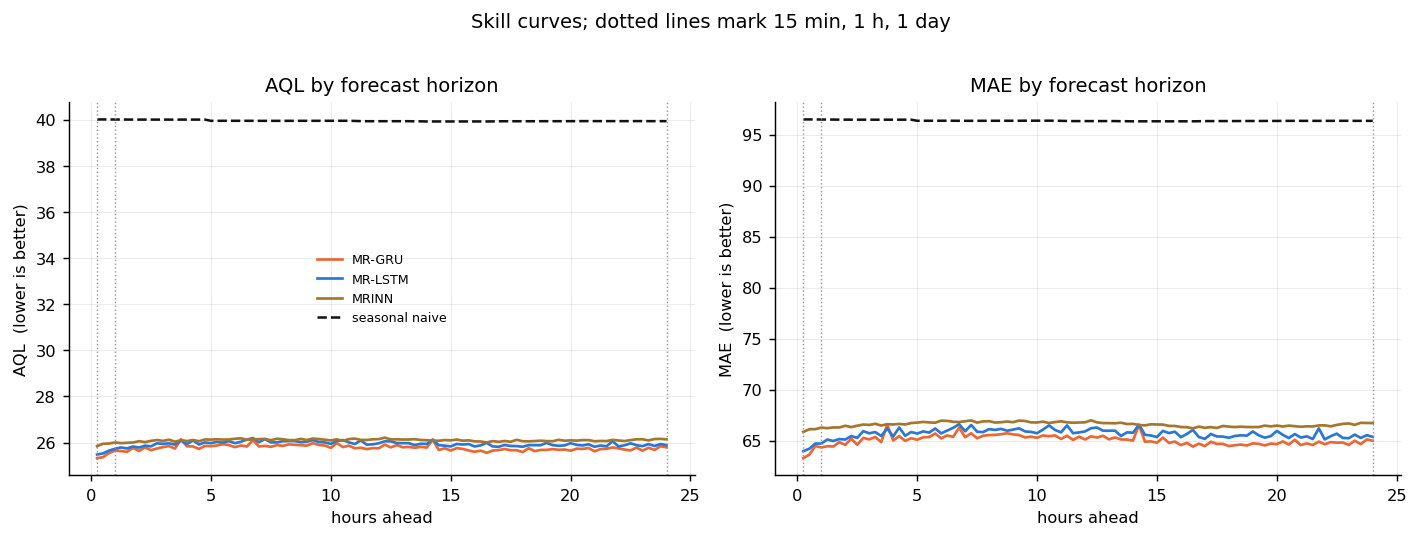

In [12]:
COL  = {"mrinn": "#a5762c", "lstm": "#2a78d6", "gru": "#eb6834"}
NAME = {"mrinn": "MRINN", "lstm": "MR-LSTM", "gru": "MR-GRU"}
plt.rcParams.update({"figure.dpi": 130, "font.size": 9, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "grid.linewidth": 0.6})

PH = pd.read_csv(HORIZON_CSV) if Path(HORIZON_CSV).exists() else pd.DataFrame()
if not PH.empty:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, metric in zip(axes, ("AQL", "MAE")):
        for tag, g in PH.groupby("tag"):
            mean_h = g.groupby("h")[metric].mean()
            ax.plot(mean_h.index * 15/60, mean_h.values, lw=1.5,
                    color=COL.get(tag, "#666"), label=NAME.get(tag, tag))
        ax.plot(NAIVE_H.h * 15/60, NAIVE_H[metric], lw=1.4, ls="--", color="#111",
                label="seasonal naive")
        for h, lbl in TARGET_HORIZONS:      # mark the three reporting horizons
            ax.axvline(h * 15/60, color="#999", lw=0.8, ls=":")
        ax.set_xlabel("hours ahead"); ax.set_ylabel(f"{metric}  (lower is better)")
        ax.set_title(f"{metric} by forecast horizon")
    axes[0].legend(fontsize=7, frameon=False)
    fig.suptitle("Skill curves; dotted lines mark 15 min, 1 h, 1 day", y=1.02)
    fig.tight_layout(); plt.show()
else:
    print("no per-horizon results yet")


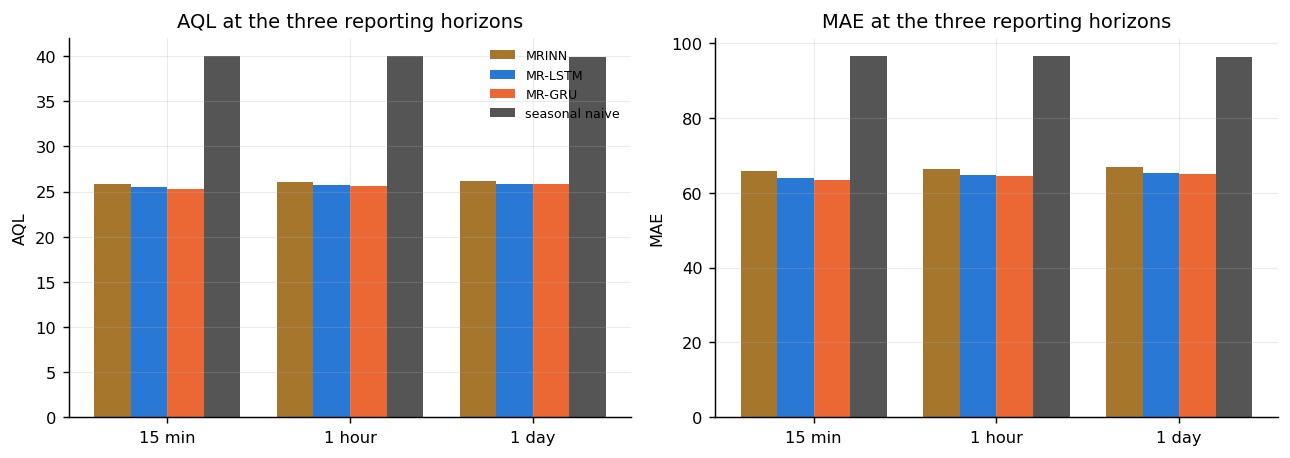

In [13]:
# --- the three reporting horizons, as grouped bars ---
if not PH.empty:
    order = ["mrinn", "lstm", "gru"]
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
    x = np.arange(len(TARGET_HORIZONS)); width = 0.2
    for ax, metric in zip(axes, ("AQL", "MAE")):
        for j, tag in enumerate(order):
            g = PH[PH.tag == tag]
            vals = [g.loc[g.h == h, metric].mean() for h, _ in TARGET_HORIZONS]
            ax.bar(x + (j - 1) * width, vals, width, color=COL[tag], label=NAME[tag])
        nv = [NAIVE_H.loc[NAIVE_H.h == h, metric].iloc[0] for h, _ in TARGET_HORIZONS]
        ax.bar(x + 2 * width, nv, width, color="#555", label="seasonal naive")
        ax.set_xticks(x + width/2); ax.set_xticklabels([lbl for _, lbl in TARGET_HORIZONS])
        ax.set_ylabel(metric); ax.set_title(f"{metric} at the three reporting horizons")
    axes[0].legend(fontsize=7, frameon=False)
    fig.tight_layout(); plt.show()


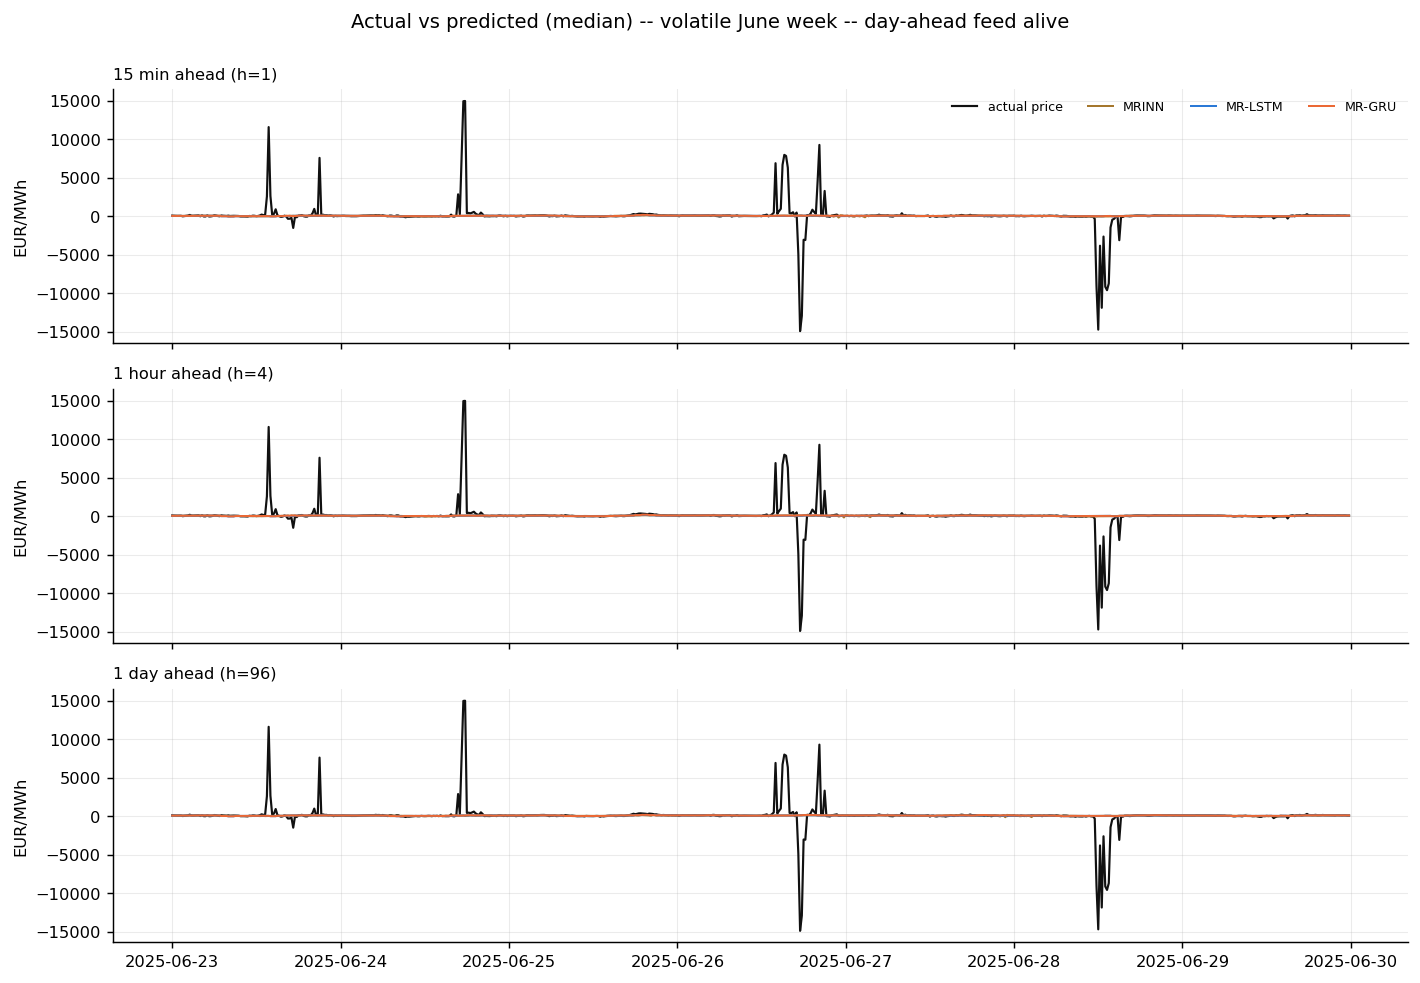

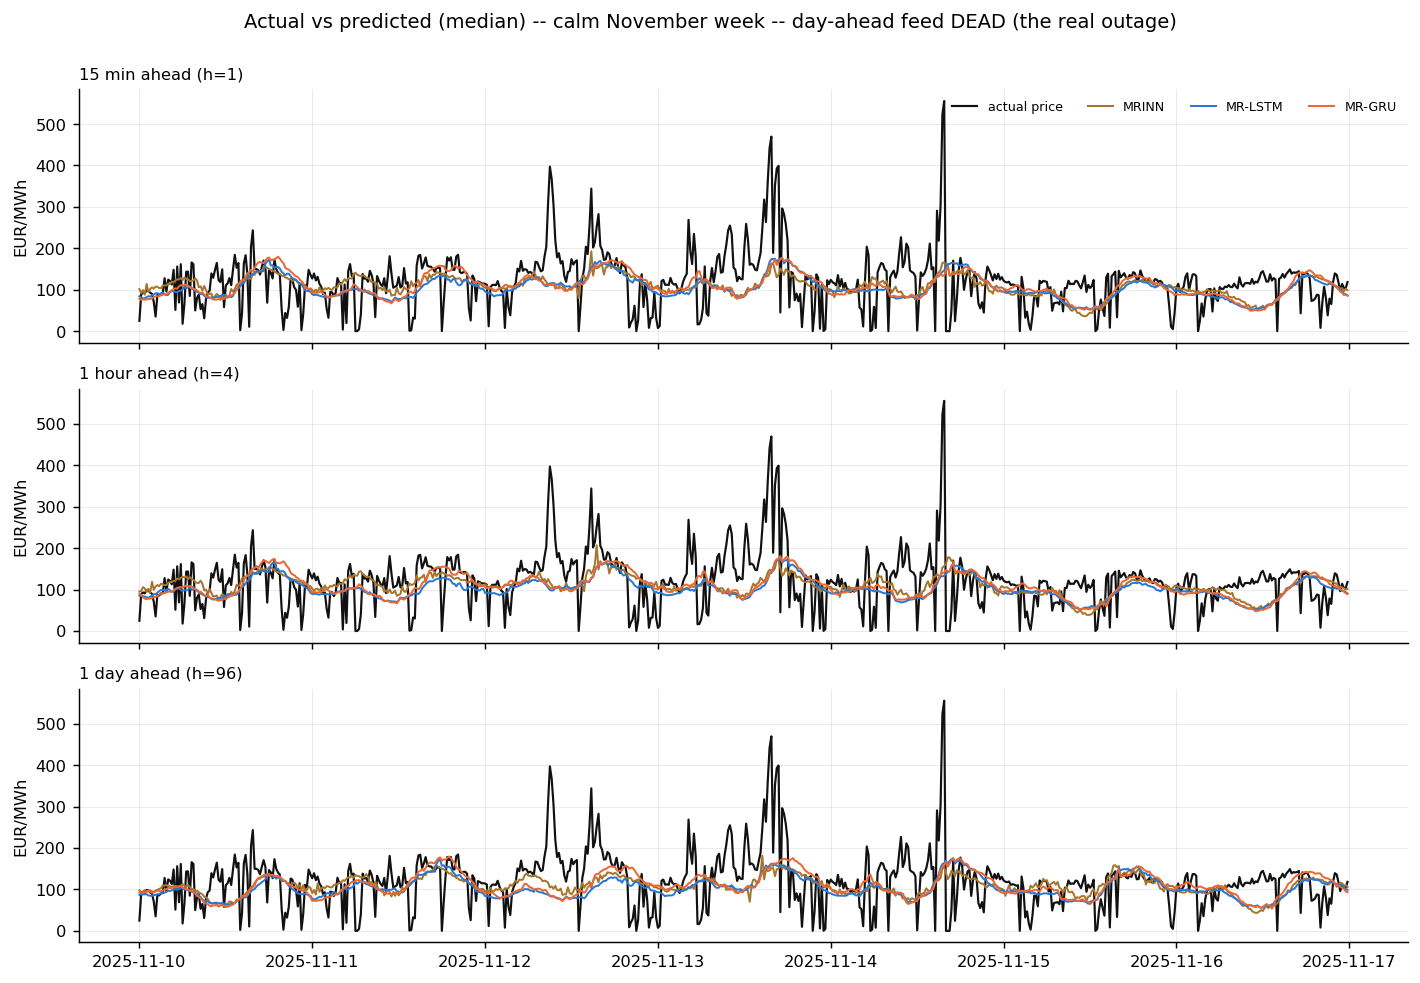

In [14]:
# --- actual price vs predicted price, at 15 min / 1 hour / 1 day ---
# Curves are drawn against the TARGET time (origin + h*15 min), so at every point the
# lines answer "what did the model say this moment's price would be, h ahead of time".
WINDOWS = [("2025-06-23", "2025-06-30", "volatile June week -- day-ahead feed alive"),
           ("2025-11-10", "2025-11-17", "calm November week -- day-ahead feed DEAD (the real outage)")]
SEED_TO_PLOT = 42
tags = [t for t in ("mrinn", "lstm", "gru")
        if f"{t}_s{SEED_TO_PLOT}_h1_q50" in PRED]
if tags:
    for w0, w1, wlbl in WINDOWS:
        t0, t1 = pd.Timestamp(w0), pd.Timestamp(w1)
        _st0 = pd.to_datetime(PRED[f"{tags[0]}_s{SEED_TO_PLOT}_stamps"])
        if not ((_st0 >= t0) & (_st0 < t1)).any():   # smoke test runs on 2024 data
            t0 = _st0.min(); t1 = t0 + pd.Timedelta(days=7)
            wlbl = f"window empty, showing first test week instead ({t0.date()})"
        fig, axes = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True)
        for ax, (h, hlbl) in zip(axes, TARGET_HORIZONS):
            drawn_actual = False
            for t in tags:
                key = f"{t}_s{SEED_TO_PLOT}"
                st = pd.to_datetime(PRED[f"{key}_stamps"]) + pd.Timedelta(minutes=15*h)
                m = (st >= t0) & (st < t1)
                if not m.any():
                    continue
                if not drawn_actual:
                    ax.plot(st[m], PRED[f"{key}_actual_h{h}"][m], color="#111",
                            lw=1.2, label="actual price")
                    drawn_actual = True
                ax.plot(st[m], PRED[f"{key}_h{h}_q50"][m], lw=1.1,
                        color=COL[t], label=NAME[t])
            ax.set_ylabel("EUR/MWh")
            ax.set_title(f"{hlbl} ahead (h={h})", loc="left", fontsize=9)
        axes[0].legend(fontsize=7, frameon=False, ncol=4)
        fig.suptitle(f"Actual vs predicted (median) -- {wlbl}", y=1.0)
        fig.tight_layout(); plt.show()
else:
    print("no stored predictions yet")


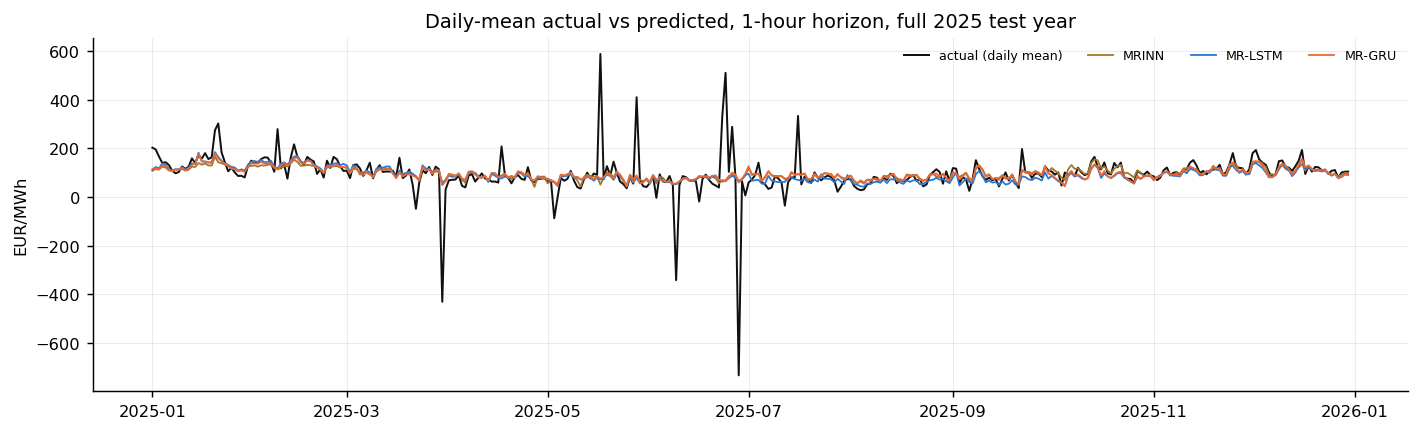

In [15]:
# --- the whole test year at a glance: daily means, 1-hour horizon ---
if tags:
    fig, ax = plt.subplots(figsize=(11, 3.4))
    drawn_actual = False
    for t in tags:
        key = f"{t}_s{SEED_TO_PLOT}"
        st = pd.to_datetime(PRED[f"{key}_stamps"]) + pd.Timedelta(hours=1)
        s = pd.Series(PRED[f"{key}_h4_q50"], index=st).resample("D").mean()
        if not drawn_actual:
            a = pd.Series(PRED[f"{key}_actual_h4"], index=st).resample("D").mean()
            ax.plot(a.index, a.values, color="#111", lw=1.1, label="actual (daily mean)")
            drawn_actual = True
        ax.plot(s.index, s.values, lw=1.0, color=COL[t], label=NAME[t])
    ax.set_ylabel("EUR/MWh"); ax.legend(fontsize=7, frameon=False, ncol=4)
    ax.set_title("Daily-mean actual vs predicted, 1-hour horizon, full 2025 test year")
    fig.tight_layout(); plt.show()


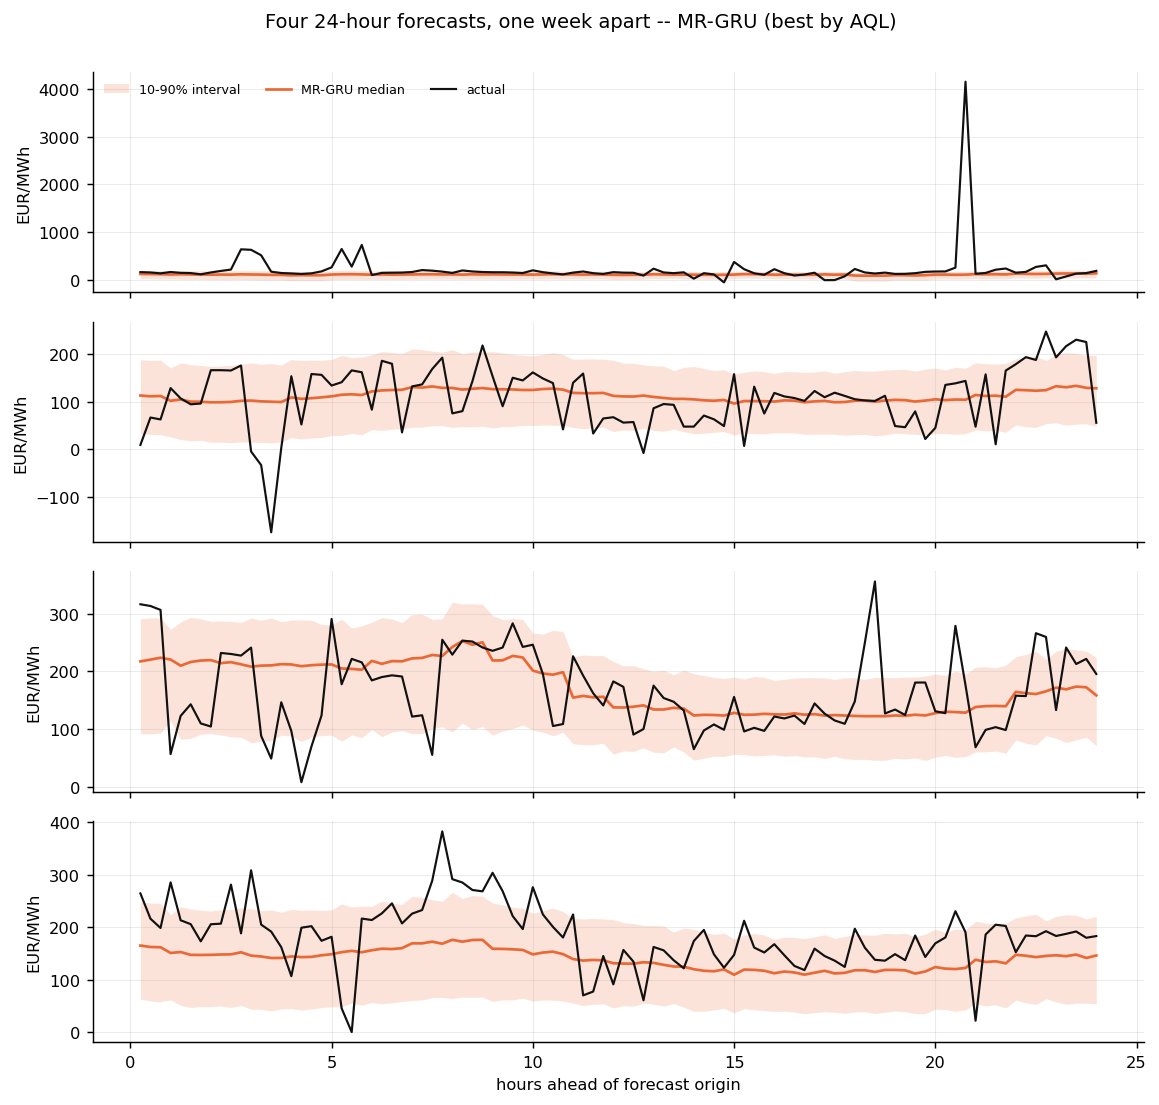

In [16]:
# --- what one full 24-hour forecast looks like, with its 80% interval ---
best_tag = None
if not load_results().empty:
    _r = load_results().groupby("tag").AQL.mean().sort_values()
    for t in _r.index:
        if f"{t}_s{SEED_TO_PLOT}_traj" in PRED:
            best_tag = t; break
if best_tag:
    key = f"{best_tag}_s{SEED_TO_PLOT}"
    traj, act = PRED[f"{key}_traj"], PRED[f"{key}_traj_actual"]
    n = min(4, len(traj), len(act))
    fig, axes = plt.subplots(n, 1, figsize=(9, 2.1*n), sharex=True)
    axes = np.atleast_1d(axes)
    hrs = np.arange(1, traj.shape[1]+1) * 15/60
    for i in range(n):
        ax = axes[i]
        ax.fill_between(hrs, traj[i, :, 0], traj[i, :, 4], color=COL[best_tag],
                        alpha=.18, lw=0, label="10-90% interval" if i == 0 else None)
        ax.plot(hrs, traj[i, :, 2], color=COL[best_tag], lw=1.5,
                label=f"{NAME[best_tag]} median" if i == 0 else None)
        ax.plot(hrs, act[i], color="#111", lw=1.2, label="actual" if i == 0 else None)
        ax.set_ylabel("EUR/MWh")
    axes[0].legend(fontsize=7, frameon=False, ncol=3)
    axes[-1].set_xlabel("hours ahead of forecast origin")
    fig.suptitle(f"Four 24-hour forecasts, one week apart -- {NAME[best_tag]} (best by AQL)",
                 y=1.005)
    fig.tight_layout(); plt.show()
else:
    print("trajectories not stored yet")


## 13. Reading this honestly

- **AQCR = 0 is inherited, not earned.** The hierarchical quantile head makes crossing
  structurally impossible for *all three* models. It says nothing about the encoder.
- **Seed noise is real.** Earlier experiments measured up to several AQL of spread for
  unlucky seed/config pairs. A difference visible on one seed only is not a result —
  compare paired by seed, and prefer the two-seed means above.
- **RMSE barely discriminates.** The test year contains prices to ±15,000 €/MWh; RMSE
  is dominated by whether a handful of spikes land, and all sane models cluster within
  ~1 €/MWh of each other. AQL and MAE are the metrics that mean something here.
- **The bounded-encoder trade-off.** The recurrent encoders' tanh-bounded state cannot
  emit runaway extreme predictions (MRINN has been observed to diverge to −49,522 €/MWh
  under an expanding protocol) — but the same boundedness makes €380 and €8,000 nearly
  indistinguishable after scaling, so all models under-respond during spikes. One
  mechanism, two consequences; report them together.
- **Expected picture at the three horizons.** At 15 min the price is ~87% determined by
  contemporaneous market state that no lagged model can see, so h=1 errors are near the
  information ceiling. At 1 day the calendar and day-ahead price carry the signal. The
  encoder mostly matters through parameter count (recurrent: constant in window length;
  Dense: linear in it), not headline accuracy — expect a near-tie on AQL with MR-GRU
  smallest.
